In [46]:
import numpy as np
import matplotlib.pyplot as plt


In [14]:
import finesse
import finesse.thermal.hello_vinet as hv
from finesse.materials import FusedSilica

In [275]:
def oned_to_twod(raveled_incides, shape):

    xys_idx = np.unravel_index(raveled_incides, shape)
    xs_idx = xys_idx[0]
    ys_idx = xys_idx[1]
    return list(zip(xys_idx[0],xys_idx[1])), xs_idx, ys_idx


Text(0.5, 1.0, 'Coating thermal deformtion')

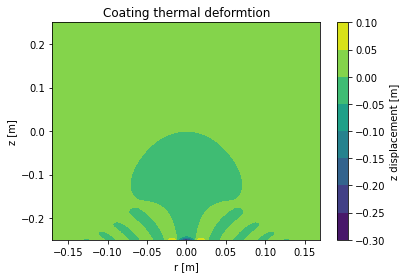

In [287]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [110]:
B = np.load("B_matrix.npy")
xy_ravel = np.load("xy_ravel_indices.npy")

In [111]:
B = np.reshape(B, (17, 1000,100))

In [12]:
a = 170e-3
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)

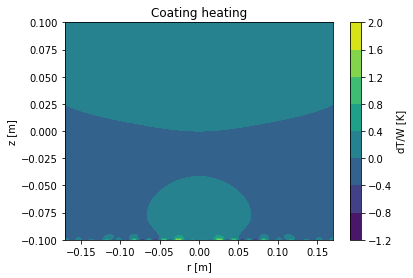

In [18]:
plt.title("Coating heating")
plt.contourf(r, z, B[9])
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.colorbar(label='dT/W [K]')

In [288]:
#xys, xs, ys = oned_to_twod(xy_ravel, len(z))
xys_idx, xs_idx, ys_idx = oned_to_twod(xy_ravel, (1000,100) )
rs = r[ys_idx]
zs = z[xs_idx]

print(rs,zs)

[-0.13909091 -0.12191919 -0.11161616 -0.10474747 -0.07727273 -0.0669697
 -0.06010101 -0.04979798 -0.03949495 -0.02232323 -0.0120202  -0.00171717
  0.01888889  0.03262626  0.08757576  0.09787879 -0.17      ] [-0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25 -0.25
 -0.25 -0.25 -0.25 -0.25  0.25]


In [289]:
xs_idx

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0, 999])

In [300]:
_U = hv.substrate_thermal_expansion_depth_HG00(rs, zs, a, h, w, FusedSilica)
print(_U[0][0], U_z_coat[0][9])

114419620472.29848 4.444912027170842e-07


In [302]:

U_z_coat_nodes_exact = np.array([U_z_coat[i] for i in xys])

U_z_coat_nodes_attempt = np.diag(hv.substrate_thermal_expansion_depth_HG00(rs, zs, a, h, w, FusedSilica))
print(U_z_coat_nodes_exact)

print(U_z_coat_nodes_attempt)

[ 4.44491203e-07 -3.53983387e-08  4.61552683e-06  3.78126607e-06
  5.19319146e-04 -2.18823334e-03 -1.98181755e-03  1.17326056e-02
 -1.55245435e-02  6.51333021e-02  4.67516205e-03 -2.92775321e-01
  9.31086661e-02 -3.76251520e-02  3.56128445e-05 -4.04234729e-05
  3.56850224e-07]
[ 1.14419620e+11 -1.63296602e+11 -1.35865482e+11 -6.32538072e+10
  1.97151144e+11  1.93334488e+11  1.13019270e+11  2.31692574e+11
  4.23226503e+11 -1.31235446e+12 -2.36876434e+12 -6.71927643e+12
  1.11147632e+12 -7.66813668e+11  1.94356586e+11  1.86591493e+11
 -4.42815241e-06]


/fred/oz170/rsmith/envs/finesse/lib/python3.8/site-packages/numpy/ma/core.py:2826: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 1.0, 'Coating thermal deformtion')

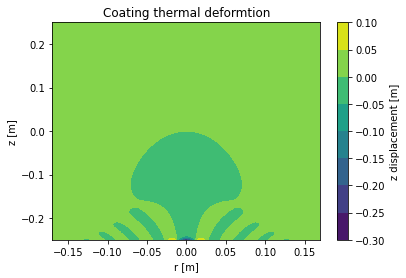

In [303]:
U_z_coat_EI = np.einsum('kij,k->ij',np.reshape(B, (17, 1000,100)), U_z_coat_nodes_exact
                       )


plt.contourf(r, z, U_z_coat_EI)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

Text(0.5, 1.0, 'Coating thermal deformtion')

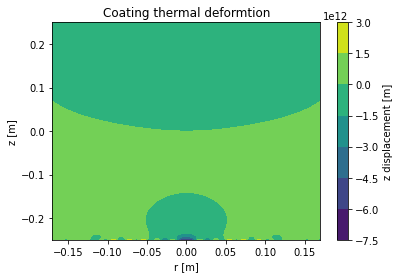

In [283]:
U_z_coat_EI = np.einsum('kij,k->ij',np.reshape(B, (17, 1000,100)), U_z_coat_nodes_attempt
                       )


plt.contourf(r, z, U_z_coat_EI)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [ ]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [113]:
B = np.load("B_matrix.npy")
xy_ravel = np.load("xy_ravel_indices.npy")

In [134]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)
U_z_coat_ravel = U_z_coat.ravel()


In [193]:
list(zip(np.unravel_index(xy_ravel, (1000,100))))

[(array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0, 999]),),
 (array([ 9, 14, 17, 19, 27, 30, 32, 35, 38, 43, 46, 49, 55, 59, 75, 78,  0]),)]

In [135]:
U_z_coat_nodes = U_z_coat_ravel[xy_ravel]

In [136]:
U_z_coat_EI = np.dot(U_z_coat_nodes, B)

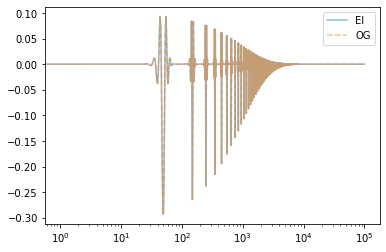

In [137]:
plt.plot(U_z_coat_EI,alpha=0.5,label='EI')
plt.plot(U_z_coat_ravel,alpha=0.5,label='OG',linestyle='--')
plt.legend()
plt.xscale("log")

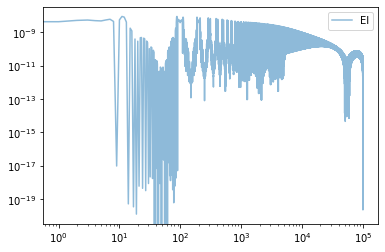

In [139]:
plt.loglog(np.abs(U_z_coat_EI-U_z_coat_ravel),alpha=0.5)
plt.legend()


Text(0.5, 1.0, 'Coating thermal deformtion')

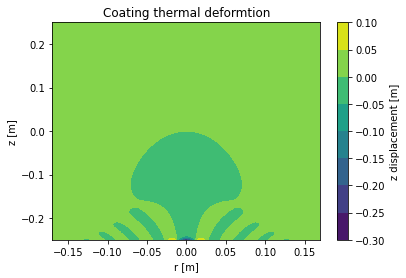

In [140]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat_EI.reshape(1000,100))
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

Text(0.5, 1.0, 'Coating thermal deformtion')

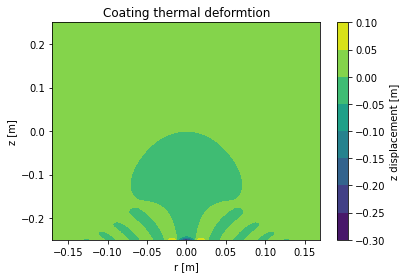

In [141]:
w = 53e-3
a = 170e-3 # radius
h = 0.2 # thickness
z = np.linspace(-0.5/2, 0.5/2, 1000)
r = np.linspace(-a, a, 100)
# z displacement throughout the substrate
U_z_coat = hv.substrate_thermal_expansion_depth_HG00(r, z, a, h, w, FusedSilica)

plt.contourf(r, z, U_z_coat_ravel.reshape(1000,100))
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [221]:
_U_z_coat_EI = np.einsum('k,kij->ij',U_z_coat_nodes, B.reshape((17,1000,100)))

/fred/oz170/rsmith/envs/finesse/lib/python3.8/site-packages/numpy/ma/core.py:2826: ComplexWarning: Casting complex values to real discards the imaginary part
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 1.0, 'Coating thermal deformtion')

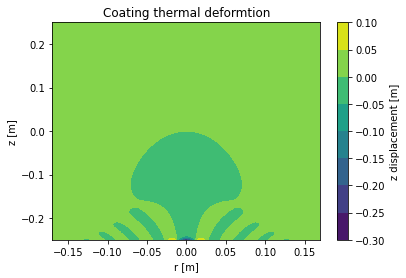

In [222]:


plt.contourf(r, z, _U_z_coat_EI)
plt.colorbar(label='z displacement [m]')
plt.xlabel("r [m]")
plt.ylabel("z [m]")
plt.title("Coating thermal deformtion")

In [212]:
np.where(U_z_coat == U_z_coat_nodes)

/tmp/ipykernel_11771/177823374.py:1: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  np.where(U_z_coat== U_z_coat_nodes)


(array([], dtype=int64),)

In [224]:
U_z_coat_nodes, U_z_coat_nodes_exact

(array([ 4.44491203e-07, -3.53983387e-08,  4.61552683e-06,  3.78126607e-06,
         5.19319146e-04, -2.18823334e-03, -1.98181755e-03,  1.17326056e-02,
        -1.55245435e-02,  6.51333021e-02,  4.67516205e-03, -2.92775321e-01,
         9.31086661e-02, -3.76251520e-02,  3.56128445e-05, -4.04234729e-05,
         3.56850224e-07]),
 array([3.52471962e-07, 3.10379045e-07, 2.97737904e-07, 2.92054790e-07,
        2.79712304e-07, 2.77050755e-07, 2.75526168e-07, 2.73471568e-07,
        2.71593275e-07, 2.68679931e-07, 2.67007379e-07, 2.65370172e-07,
        2.62170272e-07, 2.60080019e-07, 2.52003105e-07, 2.50536869e-07,
        3.02555622e-07]))

In [220]:
U_z_coat[999][0]

3.5685022427676086e-07

In [226]:
xys

[(9, 0),
 (14, 0),
 (17, 0),
 (19, 0),
 (27, 0),
 (30, 0),
 (32, 0),
 (35, 0),
 (38, 0),
 (43, 0),
 (46, 0),
 (49, 0),
 (55, 0),
 (59, 0),
 (75, 0),
 (78, 0),
 (900, 99)]

In [304]:
np.reshape(B, (17, 1000,100))

array([[[ 8.19411494e-01+0.j,  8.17143603e-01+0.j,  8.07003224e-01+0.j,
         ...,  8.07003224e-01+0.j,  8.17143603e-01+0.j,
          8.19411494e-01+0.j],
        [ 8.10965127e-01+0.j,  8.10335344e-01+0.j,  8.03145209e-01+0.j,
         ...,  8.03145209e-01+0.j,  8.10335344e-01+0.j,
          8.10965127e-01+0.j],
        [ 8.02954666e-01+0.j,  8.03685587e-01+0.j,  7.98951722e-01+0.j,
         ...,  7.98951722e-01+0.j,  8.03685587e-01+0.j,
          8.02954666e-01+0.j],
        ...,
        [-2.23550406e-04+0.j, -1.64289852e-03+0.j, -3.03111549e-03+0.j,
         ..., -3.03111549e-03+0.j, -1.64289853e-03+0.j,
         -2.23550406e-04+0.j],
        [-1.12071012e-04+0.j, -1.53136070e-03+0.j, -2.91951869e-03+0.j,
         ..., -2.91951869e-03+0.j, -1.53136070e-03+0.j,
         -1.12071012e-04+0.j],
        [ 2.89479325e-18+0.j, -1.41922775e-03+0.j, -2.80732325e-03+0.j,
         ..., -2.80732325e-03+0.j, -1.41922775e-03+0.j,
          2.89479325e-18+0.j]],

       [[-2.64820393e-02+0.j, -